In [1]:
import ir_datasets, pandas as pd

ds = ir_datasets.load("beir/nfcorpus/test")
docs = pd.DataFrame(ds.docs_iter())
queries = pd.DataFrame(ds.queries_iter())
qrels = pd.DataFrame(ds.qrels_iter())

[INFO] Opening /Users/bhagya/.ir_datasets/beir/nfcorpus/docs.pklz4/bin with direct file access


In [2]:
len(docs), len(queries), len(qrels)

(3633, 323, 12334)

In [3]:
docs.head()

,doc_id,text,title,url
0,MED-10,"Recent studies have suggested that statins, an...",Statin Use and Breast Cancer Survival: A Natio...,http://www.ncbi.nlm.nih.gov/pubmed/25329299
1,MED-14,BACKGROUND: Preclinical studies have shown tha...,Statin use after diagnosis of breast cancer an...,http://www.ncbi.nlm.nih.gov/pubmed/25304447
2,MED-118,The aims of this study were to determine the c...,Alkylphenols in human milk and their relations...,http://www.ncbi.nlm.nih.gov/pubmed/20435081%20
3,MED-301,Epilepsy or seizure disorder is one of the mos...,Methylmercury: A Potential Environmental Risk ...,http://www.ncbi.nlm.nih.gov/pubmed/22206970
4,MED-306,Hit Reaction Time latencies (HRT) in the Conti...,Sensitivity of Continuous Performance Test (CP...,http://www.ncbi.nlm.nih.gov/pubmed/20699117


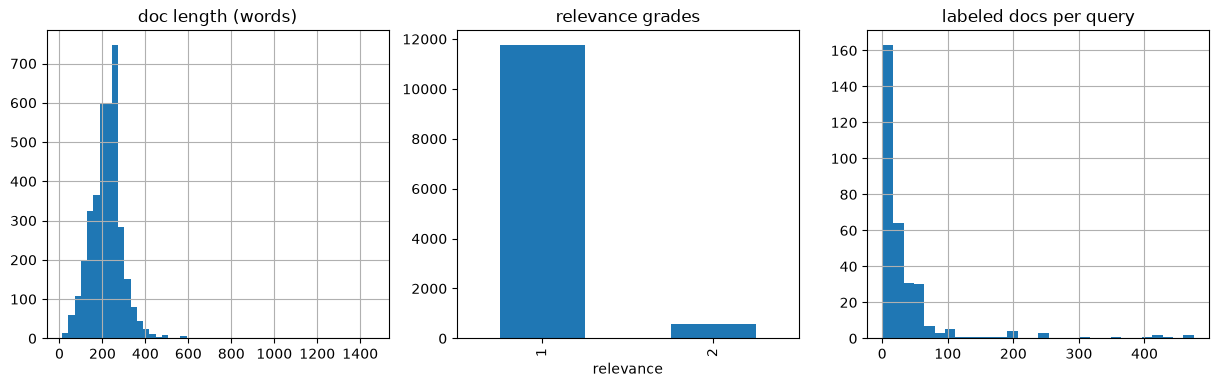

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 3, figsize=(15, 4))
docs.text.str.split().str.len().hist(bins=50, ax=ax[0])
ax[0].set_title("doc length (words)")
qrels.relevance.value_counts().sort_index().plot.bar(ax=ax[1])
ax[1].set_title("relevance grades")
qrels.groupby("query_id").size().hist(bins=30, ax=ax[2])
ax[2].set_title("labeled docs per query")
plt.show()

In [5]:
q = queries.iloc[0]
q.text

'Do Cholesterol Statin Drugs Cause Breast Cancer?'

In [6]:
qrels[qrels.query_id == q.query_id].merge(docs, on="doc_id")[["doc_id", "relevance", "title"]].sort_values("relevance", ascending=False)

,doc_id,relevance,title
0,MED-2427,2,Elevated Levels of Cholesterol-Rich Lipid Raft...
2,MED-2429,2,Statin use and risk of breast cancer: a meta-a...
3,MED-2430,2,beta-Sitosterol enhances tamoxifen effectivene...
4,MED-2431,2,Long-term statin use and risk of ductal and lo...
5,MED-14,2,Statin use after diagnosis of breast cancer an...
6,MED-2432,2,"The Garden of Eden--plant based diets, the gen..."
1,MED-10,2,Statin Use and Breast Cancer Survival: A Natio...
15,MED-3597,1,Trans Fat Consumption and Aggression
22,MED-4829,1,"Statin therapy, muscle function and falls risk..."
21,MED-4828,1,Association between statin-associated myopathy...
